# Gaussian Mixture Model (GMM) Clustering for Airbnb Listings

This notebook demonstrates how Gaussian Mixture Models (GMM) can be used to cluster Airbnb listings 
into marketing archetypes. Unlike K-Means, GMM provides *soft clustering* — each listing has a 
probability of belonging to multiple clusters. This reflects reality, where properties often appeal 
to overlapping customer segments.

In [1]:
# ---------------------------------------------------------
# STEP 1: Setup & Ingestion
# Purpose: Load ML-ready listing features and inspect schema
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

# Resolve project root (assumes notebook is in /notebooks)
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
gold_dir = project_root / "data" / "gold"

# Load ML feature table
df = pd.read_parquet(gold_dir / "ml_listing_features.parquet")

print(f"✅ Loaded {len(df):,} listings")
df.info()
df.head()

✅ Loaded 94,559 listings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94559 entries, 0 to 94558
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         94559 non-null  int64         
 1   host_id                    94559 non-null  int64         
 2   room_type                  94559 non-null  category      
 3   neighbourhood_cleansed     94559 non-null  category      
 4   price                      60341 non-null  float64       
 5   host_is_superhost          94559 non-null  int64         
 6   host_response_rate         60416 non-null  Float64       
 7   review_scores_rating       94559 non-null  float64       
 8   beds                       60282 non-null  float64       
 9   accommodates               94559 non-null  int64         
 10  minimum_nights             94559 non-null  int64         
 11  maximum_nights             94559 non-null 

,id,host_id,room_type,neighbourhood_cleansed,price,host_is_superhost,host_response_rate,review_scores_rating,beds,accommodates,...,number_of_reviews,future_calendar_days,future_available_days,future_avg_price,future_occupancy_rate,review_count,first_review_date,last_review_date,reviews_per_month,beds_imputed
0,91031,491004,Entire home/apt,Wandsworth,94.0,0,88.0,4.23,1.0,2,...,25,365.0,72.0,99.0,0.802740,25,2011-05-03,2025-03-05,0.148368,1.0
1,91287,493497,Entire home/apt,Islington,NaN,0,100.0,4.51,NaN,4,...,66,365.0,0.0,185.0,1.000000,66,2011-05-17,2024-12-04,0.400000,2.0
2,92352,497172,Entire home/apt,Islington,NaN,1,100.0,4.86,NaN,2,...,73,365.0,0.0,110.0,1.000000,73,2016-12-11,2024-12-02,0.751802,2.0
3,92399,497366,Entire home/apt,Islington,86.0,1,100.0,4.84,1.0,2,...,317,365.0,288.0,100.0,0.210959,317,2011-07-05,2025-02-27,1.907341,1.0
4,93015,499704,Entire home/apt,Hammersmith and Fulham,175.0,0,<NA>,4.85,3.0,5,...,40,365.0,33.0,180.0,0.909589,40,2012-02-01,2024-11-14,0.256959,3.0


In [2]:
# ---------------------------------------------------------
# STEP 2: Initial Data Audit
# Purpose: Check nulls, dtypes, and basic distributions
# ---------------------------------------------------------

# Null counts
nulls = df.isnull().sum().sort_values(ascending=False)
print("🔍 Nulls per column:\n", nulls[nulls > 0])

# Descriptive stats
df.describe().T

# Quick look at categorical flags
print("🧮 Unique room types:", df["room_type"].unique())
print("🧮 Unique neighbourhoods:", df["neighbourhood_cleansed"].nunique())

🔍 Nulls per column:
 beds                       34277
price                      34218
host_response_rate         34143
last_review_date           24244
first_review_date          24244
future_calendar_days           5
estimated_revenue_l365d        5
future_available_days          5
future_avg_price               5
future_occupancy_rate          5
beds_imputed                   5
dtype: int64
🧮 Unique room types: ['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']
Categories (4, object): ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']
🧮 Unique neighbourhoods: 33


In [3]:
df.describe()

,id,host_id,price,host_is_superhost,host_response_rate,review_scores_rating,beds,accommodates,minimum_nights,maximum_nights,...,number_of_reviews,future_calendar_days,future_available_days,future_avg_price,future_occupancy_rate,review_count,first_review_date,last_review_date,reviews_per_month,beds_imputed
count,9.455900e+04,9.455900e+04,60341.000000,94559.000000,60416.0,94559.000000,60282.000000,94559.000000,94559.000000,9.455900e+04,...,94559.000000,94554.000000,94554.000000,94554.000000,94554.000000,94559.0,70315,70315,94559.000000,94554.000000
mean,6.066726e+17,2.003118e+08,185.482624,0.177593,92.675401,3.489244,1.932102,3.299337,5.482704,6.215041e+03,...,20.434491,365.002232,134.234670,269.660089,0.632230,20.434438,2021-08-28 16:12:38.552229120,2023-07-23 08:50:12.500889088,1.422220,1.820209
min,1.391300e+04,2.594000e+03,6.000000,0.000000,0.0,0.000000,0.000000,1.000000,1.000000,1.000000e+00,...,0.000000,350.000000,0.000000,0.000000,0.000000,0.0,2009-12-21 00:00:00,2011-07-02 00:00:00,0.000000,1.000000
25%,2.809901e+07,2.572771e+07,71.000000,0.000000,99.0,0.000000,1.000000,2.000000,1.000000,6.000000e+01,...,0.000000,365.000000,0.000000,67.000000,0.263014,0.0,2018-12-30 00:00:00,2023-06-27 00:00:00,0.000000,1.000000
50%,7.511326e+17,1.057565e+08,120.000000,0.000000,100.0,4.680000,1.000000,2.000000,2.000000,3.650000e+02,...,4.000000,365.000000,88.000000,120.000000,0.758904,4.0,2022-12-04 00:00:00,2024-10-31 00:00:00,0.530973,2.000000
75%,1.141072e+18,3.760111e+08,197.000000,0.000000,100.0,4.960000,2.000000,4.000000,4.000000,1.125000e+03,...,19.000000,365.000000,269.000000,200.000000,1.000000,19.0,2024-05-06 00:00:00,2025-02-03 00:00:00,1.714286,2.000000
max,1.368871e+18,6.819521e+08,74100.000000,1.000000,100.0,5.000000,50.000000,16.000000,1125.000000,5.248556e+08,...,1791.000000,366.000000,366.000000,80000.000000,1.000000,1791.0,2025-03-14 00:00:00,2025-03-15 00:00:00,90.000000,50.000000
std,5.481489e+17,2.068400e+08,604.807337,0.382172,21.114495,2.090986,1.439265,2.063247,23.157895,1.707381e+06,...,48.854856,0.464565,136.288298,1069.277493,0.373383,48.854875,NaN,NaN,3.202008,1.175600


In [4]:
# REMAINING Missingness Cleanup Strategy

#DROP
df = df.drop(columns=[
    "beds",                # replaced by beds_imputed
    "price",               # replaced by future_avg_price
    "first_review_date",   # not needed for clustering
    "last_review_date"     # same
])

df.head()

,id,host_id,room_type,neighbourhood_cleansed,host_is_superhost,host_response_rate,review_scores_rating,accommodates,minimum_nights,maximum_nights,...,estimated_occupancy_l365d,number_of_reviews_ltm,number_of_reviews,future_calendar_days,future_available_days,future_avg_price,future_occupancy_rate,review_count,reviews_per_month,beds_imputed
0,91031,491004,Entire home/apt,Wandsworth,0,88.0,4.23,2,6,89,...,48,4,25,365.0,72.0,99.0,0.802740,25,0.148368,1.0
1,91287,493497,Entire home/apt,Islington,0,100.0,4.51,4,1,365,...,37,4,66,365.0,0.0,185.0,1.000000,66,0.400000,2.0
2,92352,497172,Entire home/apt,Islington,1,100.0,4.86,2,3,121,...,129,14,73,365.0,0.0,110.0,1.000000,73,0.751802,2.0
3,92399,497366,Entire home/apt,Islington,1,100.0,4.84,2,1,365,...,239,26,317,365.0,288.0,100.0,0.210959,317,1.907341,1.0
4,93015,499704,Entire home/apt,Hammersmith and Fulham,0,<NA>,4.85,5,5,1125,...,30,3,40,365.0,33.0,180.0,0.909589,40,0.256959,3.0


In [5]:
df

,id,host_id,room_type,neighbourhood_cleansed,host_is_superhost,host_response_rate,review_scores_rating,accommodates,minimum_nights,maximum_nights,...,estimated_occupancy_l365d,number_of_reviews_ltm,number_of_reviews,future_calendar_days,future_available_days,future_avg_price,future_occupancy_rate,review_count,reviews_per_month,beds_imputed
0,91031,491004,Entire home/apt,Wandsworth,0,88.0,4.23,2,6,89,...,48,4,25,365.0,72.0,99.0,0.802740,25,0.148368,1.0
1,91287,493497,Entire home/apt,Islington,0,100.0,4.51,4,1,365,...,37,4,66,365.0,0.0,185.0,1.000000,66,0.400000,2.0
2,92352,497172,Entire home/apt,Islington,1,100.0,4.86,2,3,121,...,129,14,73,365.0,0.0,110.0,1.000000,73,0.751802,2.0
3,92399,497366,Entire home/apt,Islington,1,100.0,4.84,2,1,365,...,239,26,317,365.0,288.0,100.0,0.210959,317,1.907341,1.0
4,93015,499704,Entire home/apt,Hammersmith and Fulham,0,<NA>,4.85,5,5,1125,...,30,3,40,365.0,33.0,180.0,0.909589,40,0.256959,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94554,1368870872086306940,446820235,Entire home/apt,Wandsworth,0,100.0,0.00,2,1,365,...,0,0,0,365.0,363.0,14940.0,0.005479,0,0.000000,2.0
94555,1368654193436336059,575169632,Entire home/apt,Westminster,0,100.0,0.00,2,1,1125,...,0,0,0,365.0,359.0,169.0,0.016438,0,0.000000,1.0
94556,1368654300360647872,575169632,Entire home/apt,Westminster,0,100.0,0.00,3,1,1125,...,0,0,0,365.0,325.0,169.0,0.109589,0,0.000000,2.0
94557,1368654396416090664,575169632,Entire home/apt,Westminster,0,100.0,0.00,3,1,1125,...,0,0,0,365.0,291.0,149.0,0.202740,0,0.000000,2.0


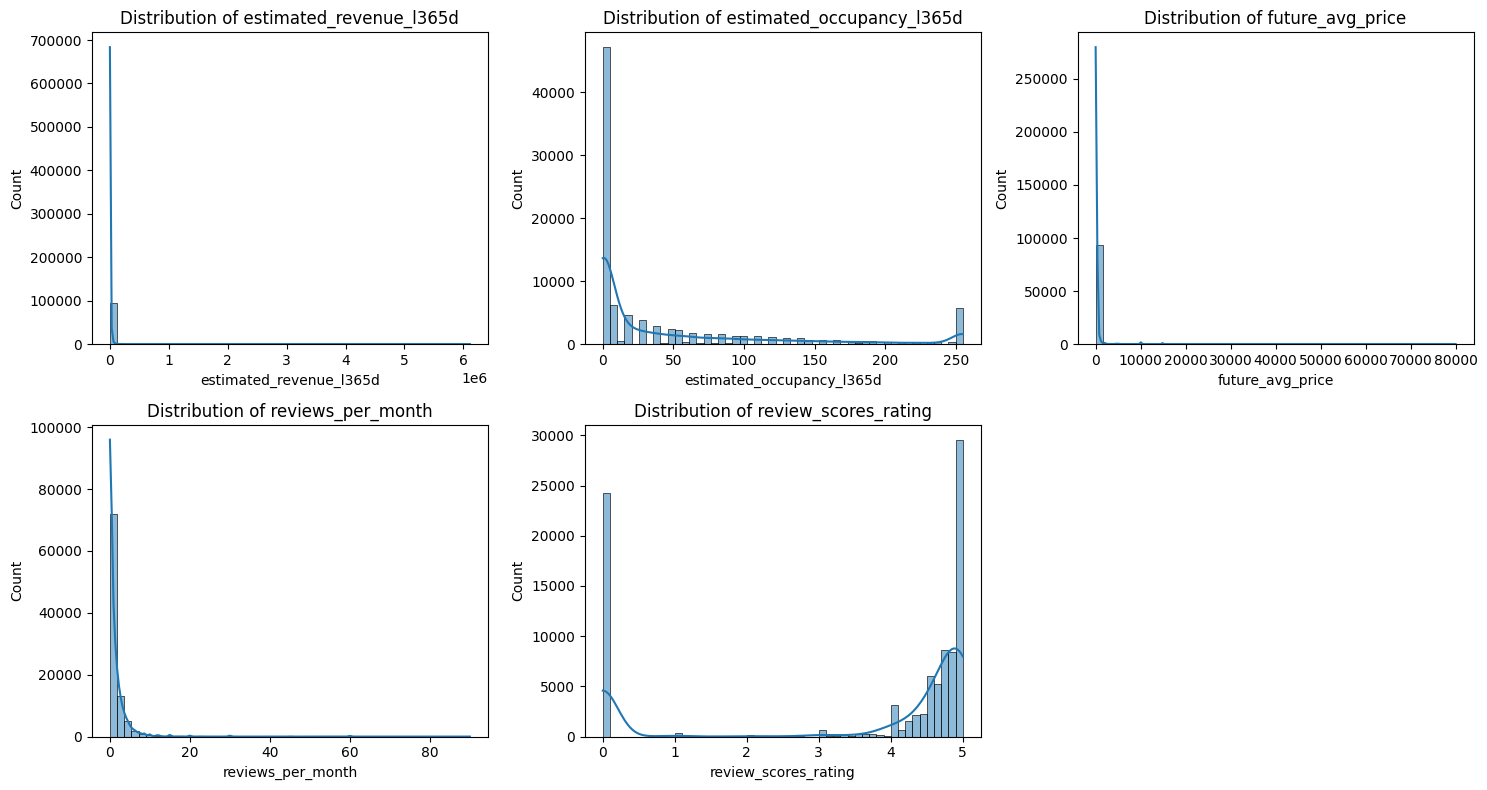

In [6]:
# ---------------------------------------------------------
# STEP 3: EDA - Raw Distributions of Core Features
# Purpose: Inspect main clustering signals before transforms
# ---------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

core_features = [
    "estimated_revenue_l365d",   # Annual revenue signal
    "estimated_occupancy_l365d", # Booking frequency
    "future_avg_price",          # Host pricing strategy
    "reviews_per_month",         # Engagement velocity
    "review_scores_rating"       # Guest satisfaction
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(core_features):
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Remove empty subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## 📊 Observations from Raw Feature Distributions

We inspected the raw distributions of five core features that will likely drive our clustering model:

### 1. `estimated_revenue_l365d`
- **Observation:** Highly right-skewed. Most listings generate modest revenue, with a long tail of high earners.
- **Action:** Apply `log1p` transform to compress the tail and reveal structure in the mid-range. Consider winsorizing extreme values if needed.

### 2. `estimated_occupancy_l365d`
- **Observation:** Majority of listings show low-to-moderate occupancy, but some engineered values are extremely high.
- **Action:** Cap at a sensible threshold (e.g., 99th percentile) to prevent distortion in clustering. No transform needed.

### 3. `future_avg_price`
- **Observation:** Strong skew toward lower prices, with a few listings priced in the tens of thousands.
- **Action:** Apply `log1p` transform to stabilize scale. This helps differentiate pricing strategies without letting outliers dominate.

### 4. `reviews_per_month`
- **Observation:** Most listings receive fewer than 2 reviews/month. A small subset shows high engagement velocity.
- **Action:** Use `log1p` to reveal structure in the low-activity range. This feature helps distinguish high-performing listings.

### 5. `review_scores_rating`
- **Observation:** Bimodal distribution with many listings unrated (0) and many clustered near 5.0.
- **Action:** Treat zeros as missing (not “bad”) to avoid pulling clusters toward a false anchor. No transform needed.

---

These observations guide our preprocessing strategy: log transforms for skewed features, capping for engineered extremes, and careful treatment of missing values. This ensures our clustering model reflects meaningful business variation rather than technical noise.

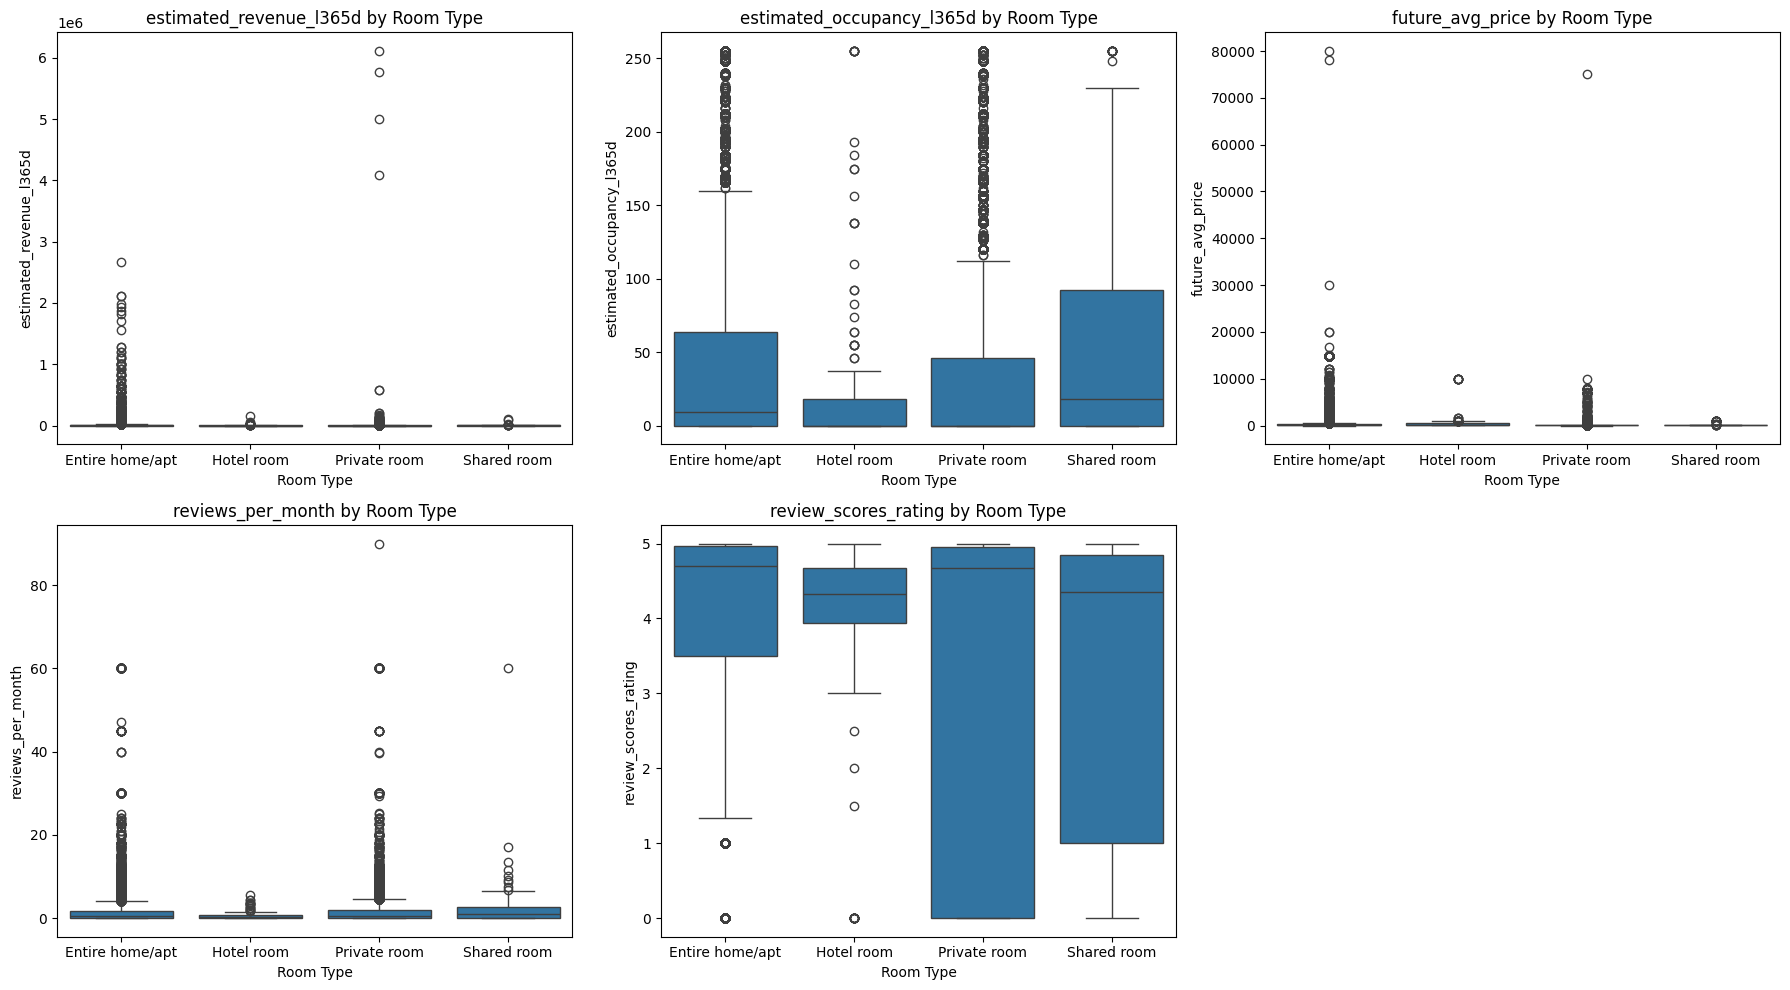

In [7]:
# ---------------------------------------------------------
# STEP 4: EDA - Boxplots by Room Type
# Purpose: Compare feature distributions across room types
# ---------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# Define core features to plot
core_features = [
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "future_avg_price",
    "reviews_per_month",
    "review_scores_rating"
]

# Set up plot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot each feature by room type
for i, col in enumerate(core_features):
    sns.boxplot(data=df, x="room_type", y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Room Type")
    axes[i].set_xlabel("Room Type")
    axes[i].set_ylabel(col)

# Remove empty subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## 📦 Boxplot Analysis by Room Type

We examined how key performance features vary across room types using boxplots. This helps us understand structural differences and identify outliers that may distort clustering.

### 1. `estimated_revenue_l365d`
- **Observation:** Entire home/apt listings dominate revenue, with a wide spread and extreme outliers. Hotel rooms show high variance but fewer listings.
- **Action:** Apply `log1p` transform to compress the long tail. Consider capping extreme values (e.g., top 0.5%) to stabilize clustering.

### 2. `estimated_occupancy_l365d`
- **Observation:** Entire homes again show the widest spread. Shared and private rooms have tighter distributions. Some extreme values suggest engineered artifacts.
- **Action:** Cap occupancy at a sensible threshold (e.g., 99th percentile). No transform needed unless skew persists post-capping.

### 3. `future_avg_price`
- **Observation:** Hotel rooms and entire homes show higher pricing, but hotel room variance is extreme. Shared rooms are predictably low.
- **Action:** Apply `log1p` transform to normalize pricing. Consider winsorizing hotel room prices to reduce distortion.

### 4. `reviews_per_month`
- **Observation:** Most room types show low review velocity, but hotel rooms and some private rooms have high outliers.
- **Action:** Use `log1p` to reveal structure in low-activity listings. This feature helps distinguish high-engagement properties.

### 5. `review_scores_rating`
- **Observation:** All room types cluster near 5.0, with some unrated listings at 0. Distribution is tight, with little room-type differentiation.
- **Action:** Treat zeros as missing (not “bad”). No transform needed. Consider excluding unrated listings from clustering if they dilute signal.

---

These insights guide our preprocessing strategy: log transforms for skewed features, capping for engineered or policy-driven extremes, and careful treatment of missing values. Room type itself will be used later to profile clusters, not to drive them.

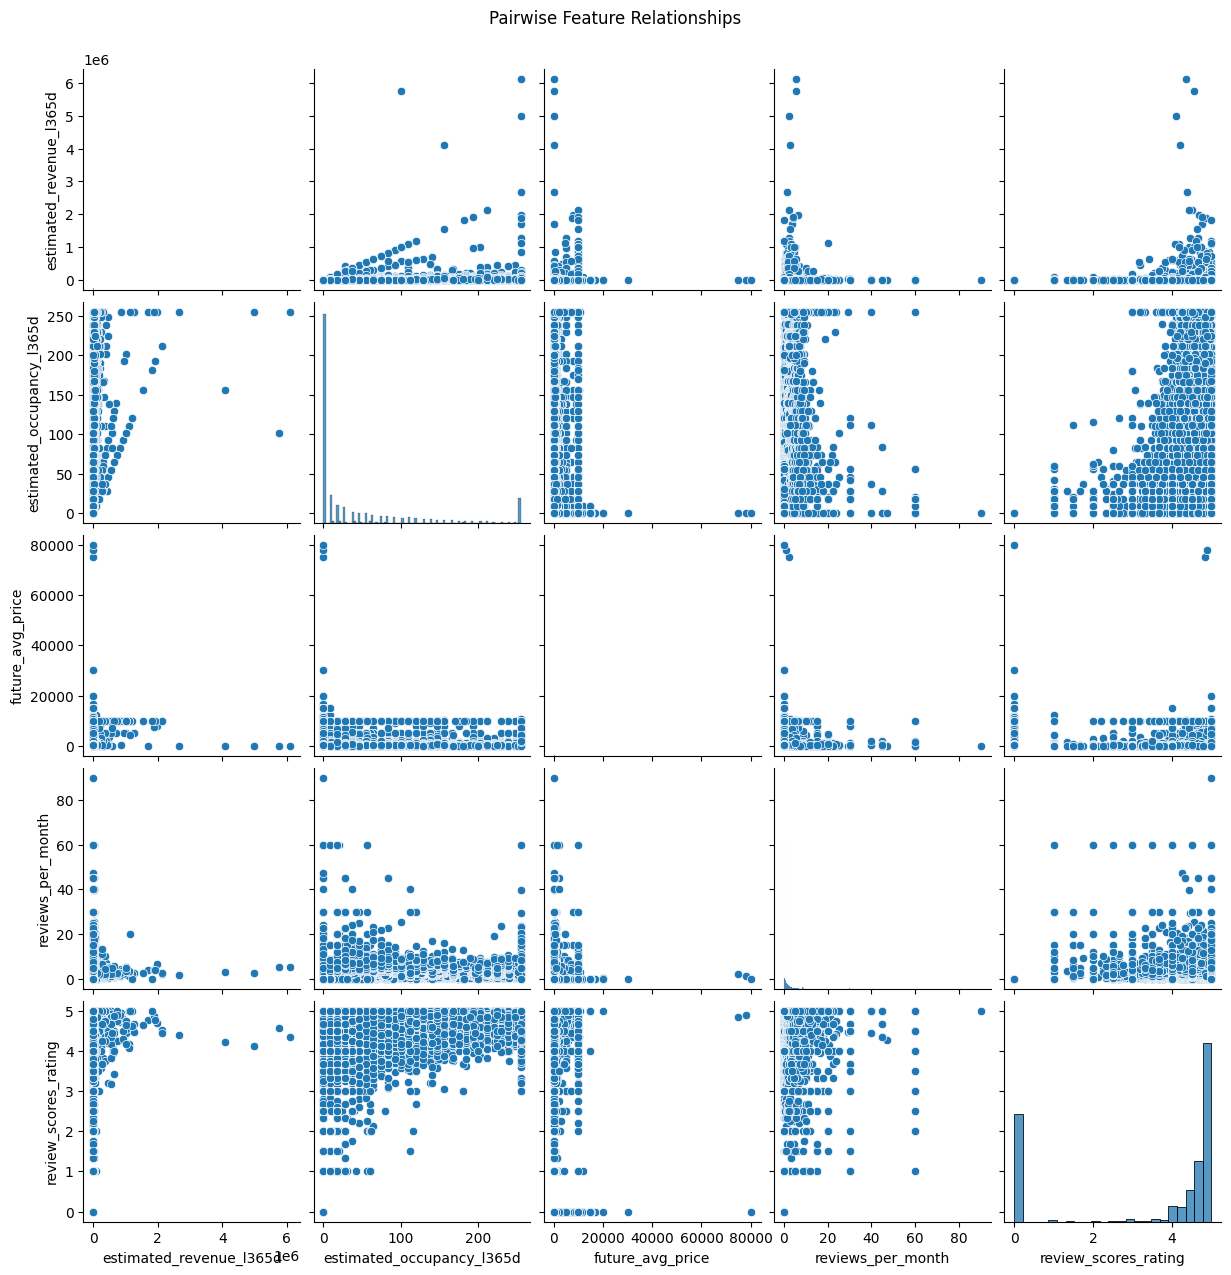

In [8]:
# ---------------------------------------------------------
# Pairplot: Key Feature Relationships
# Purpose: Explore pairwise relationships between core metrics.
# Helps identify linear/nonlinear trends, clusters, and correlations.
# Includes review_scores_rating to assess satisfaction vs performance.
# ---------------------------------------------------------

sns.pairplot(df[[
    "estimated_revenue_l365d",       # Annual revenue signal
    "estimated_occupancy_l365d",     # Booking frequency
    "future_avg_price",              # Host pricing strategy
    "reviews_per_month",             # Engagement velocity
    "review_scores_rating"           # Guest satisfaction
]])

# Add a title above the grid
plt.suptitle("Pairwise Feature Relationships", y=1.02)

# Show the plot
plt.show()

🔍 Key Takeaways from the Pairplot
1. Revenue vs Occupancy: Strong Positive Correlation
- Listings with higher occupancy tend to earn more — no surprise, but it confirms that booking frequency is a key revenue driver
- Suggests that occupancy could be a proxy for demand or host commitment
2. Revenue vs Price: Weak or No Clear Correlation
- High nightly price doesn’t guarantee high revenue — likely because expensive listings may have lower occupancy
- Reinforces the idea that pricing strategy must be paired with availability and demand
3. Reviews per Month vs Revenue/Occupancy: Moderate Positive Relationship
- Listings with frequent reviews tend to be more booked and earn more
- Indicates that review velocity is a solid engagement signal, possibly tied to visibility or guest satisfaction
4. Review Scores Rating: Weakly Correlated Across the Board
- Most listings cluster around high scores (4.5–5), so there's limited variance
- Doesn’t strongly predict revenue, occupancy, or review velocity — but could still help flag quality tiers or filter out poor performers

🧠 Strategic Implications
- Occupancy is your strongest behavioral anchor — it drives revenue and reflects listing activity
- Price alone is not predictive — it needs to be contextualized with occupancy and review velocity
- Review scores are saturated — useful for filtering, but not for clustering unless you isolate low performers
- Reviews per month is a sleeper hit — it captures engagement and churn better than total review count


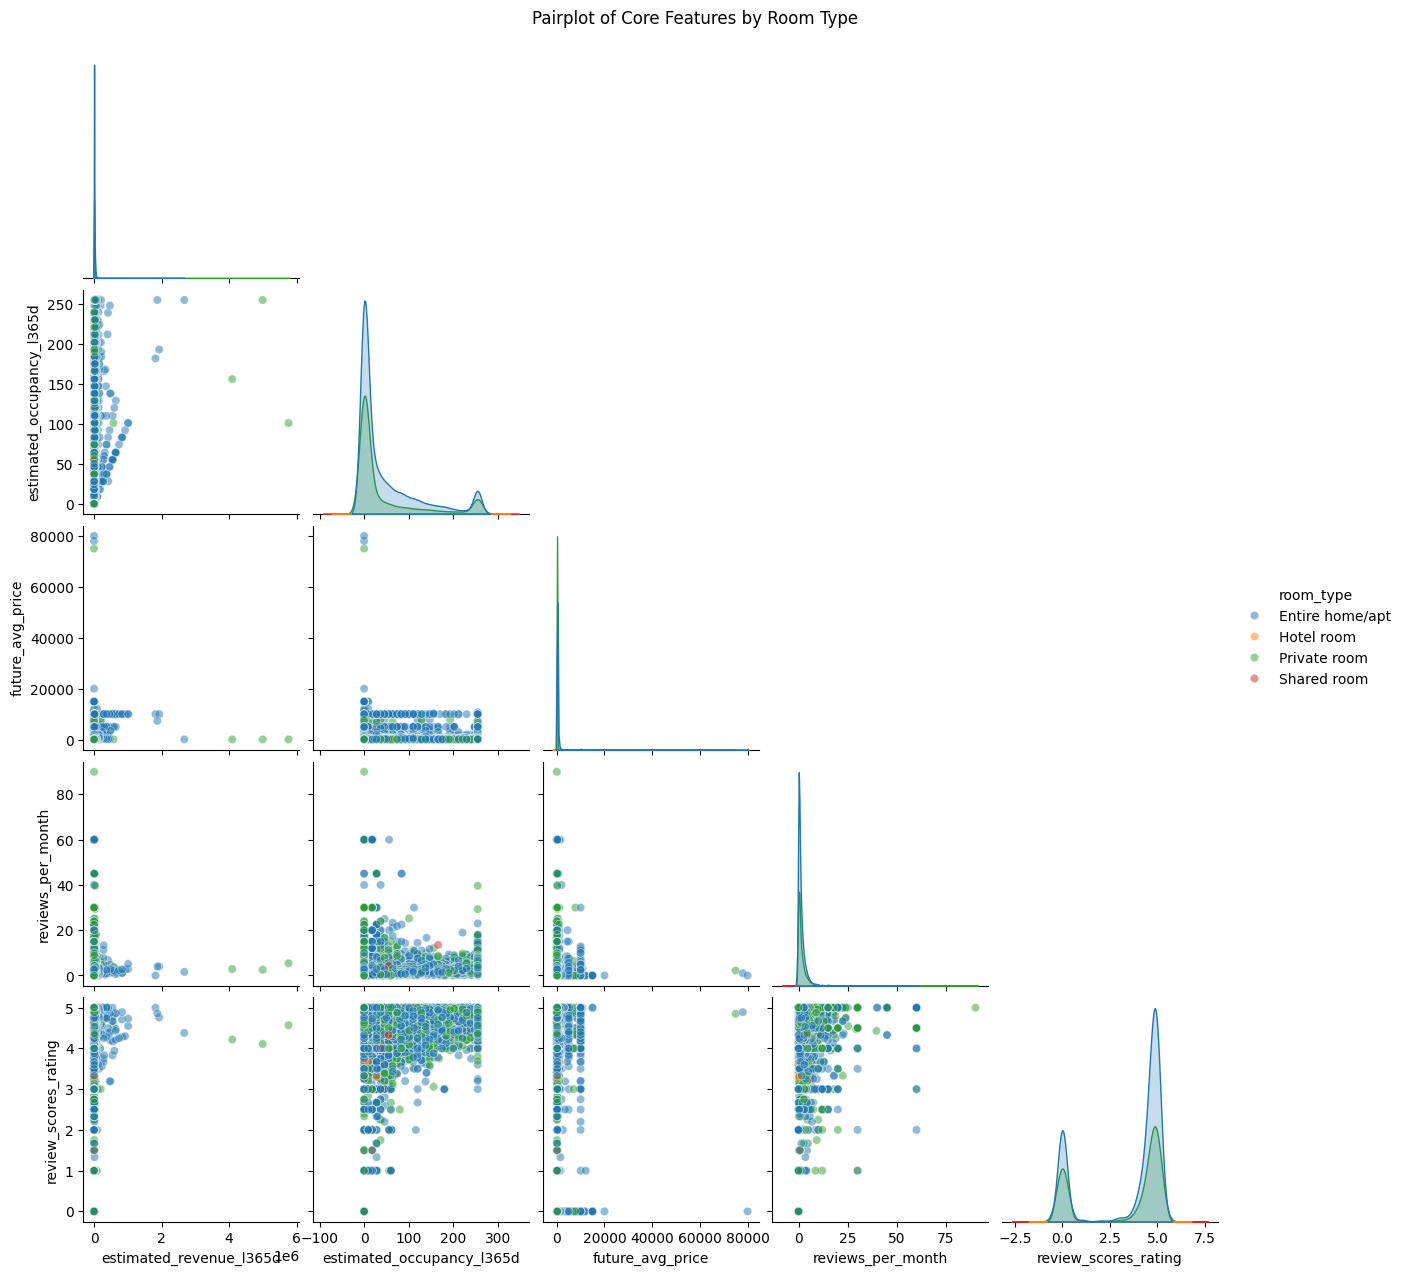

In [9]:
# ---------------------------------------------------------
# STEP 5: EDA - Pairplot of Core Features
# Purpose: Explore feature relationships and room type separability
# ---------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# Select subset of features for pairplot (avoid extreme skew)
pairplot_features = [
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "future_avg_price",
    "reviews_per_month",
    "review_scores_rating"
]

# Drop rows with missing values in selected features
df_pairplot = df[pairplot_features + ["room_type"]].dropna()

# Sample if needed (pairplot can be slow on large datasets)
df_sample = df_pairplot.sample(n=50000, random_state=42) if len(df_pairplot) > 3000 else df_pairplot

# Plot pairplot
sns.pairplot(df_sample, hue="room_type", corner=True, plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot of Core Features by Room Type", y=1.02)
plt.show()

## 🔍 Pairplot Analysis: Feature Relationships by Room Type

We visualized five core features using a pairplot, with `room_type` as the hue. This helps assess natural separability, overlap, and feature interactions before clustering.

### Key Observations

- **Revenue vs. Price:** Entire homes and hotel rooms dominate the high-revenue, high-price space. Private and shared rooms cluster tightly at lower values.
- **Occupancy vs. Reviews:** Listings with higher occupancy tend to receive more reviews per month, especially among entire homes. This suggests engagement velocity is a proxy for demand.
- **Rating vs. Everything:** Review scores are tightly clustered near 5.0 across all room types, offering limited differentiation. Many listings are unrated (0), which appear as a separate band.
- **Room Type Overlap:**  
  - Entire homes form a distinct cloud in most plots.  
  - Private and shared rooms overlap heavily, especially in low-price, low-revenue regions.  
  - Hotel rooms are sparse but show extreme values — likely outliers or engineered listings.

### Modeling Implications

- **Clustering is justified:** There is visible structure in the data — especially between high-performing entire homes and lower-tier private/shared rooms.
- **Soft clustering preferred:** Overlap between room types (e.g., private vs. shared) supports the use of Gaussian Mixture Models, which allow probabilistic membership.
- **Feature selection validated:** The chosen features show meaningful variation and interaction, confirming their relevance for clustering.

---

This analysis supports our decision to use GMM for nuanced persona discovery. It also shows that room type, while not used in modeling, aligns with natural clusters and will be valuable for post-hoc interpretation.

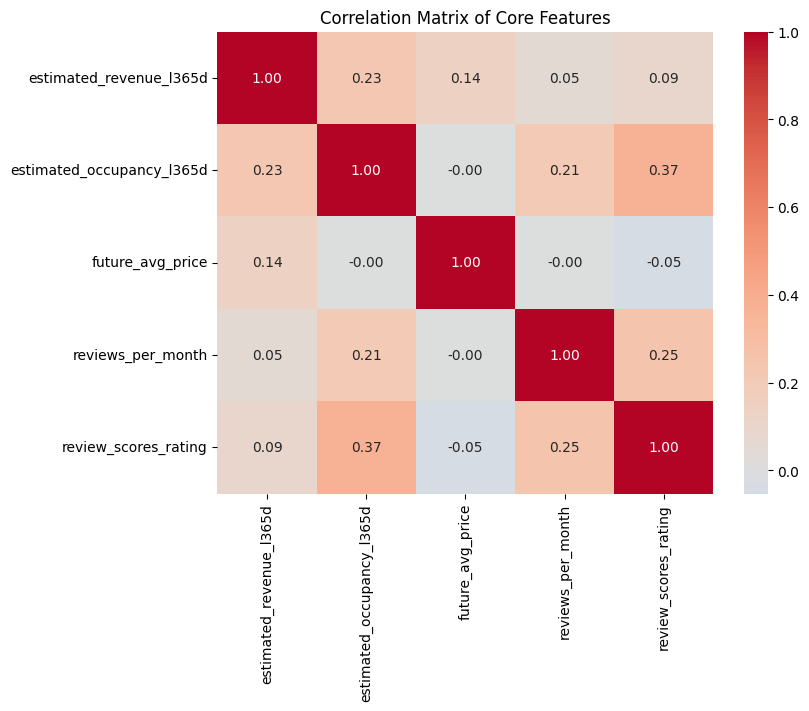

In [10]:
# ---------------------------------------------------------
# STEP 6: EDA - Correlation Matrix
# Purpose: Assess relationships and redundancy among core features
# ---------------------------------------------------------

# Select core features
corr_features = [
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "future_avg_price",
    "reviews_per_month",
    "review_scores_rating"
]

# Drop missing values
df_corr = df[corr_features].dropna()

# Compute Pearson correlation
corr_matrix = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Core Features")
plt.show()

## 🔗 Correlation Matrix Insights

We examined Pearson correlations between five core features to assess redundancy and feature interactions before clustering.

### Key Observations

- **Low overall correlation:** Most feature pairs show weak relationships (r < 0.25), suggesting they capture distinct behavioral signals.
- **Revenue vs. Occupancy (r = 0.23):** Modest positive correlation. Listings booked more often tend to earn more, but the relationship is not linear — pricing and other factors matter.
- **Revenue vs. Price (r = 0.14):** Weak correlation. High prices don’t guarantee high revenue, reinforcing the need to model pricing and demand separately.
- **Occupancy vs. Rating (r = 0.37):** Moderate correlation. Listings with higher guest satisfaction tend to be booked more often.
- **Reviews per Month vs. Rating (r = 0.25):** Slight positive correlation. High-rated listings receive more reviews, but the effect is modest.

### Modeling Implications

- **No redundancy:** All five features contribute unique information. No pair is strongly collinear.
- **Clustering justified:** The weak correlations suggest that clustering will uncover latent structure not visible through linear relationships.
- **Feature selection validated:** Each variable reflects a different dimension of listing performance — revenue, demand, pricing, engagement, and satisfaction.

---

This matrix confirms that our feature set is diverse and business-relevant. We’ll retain all five for clustering and apply scaling to ensure balanced influence.

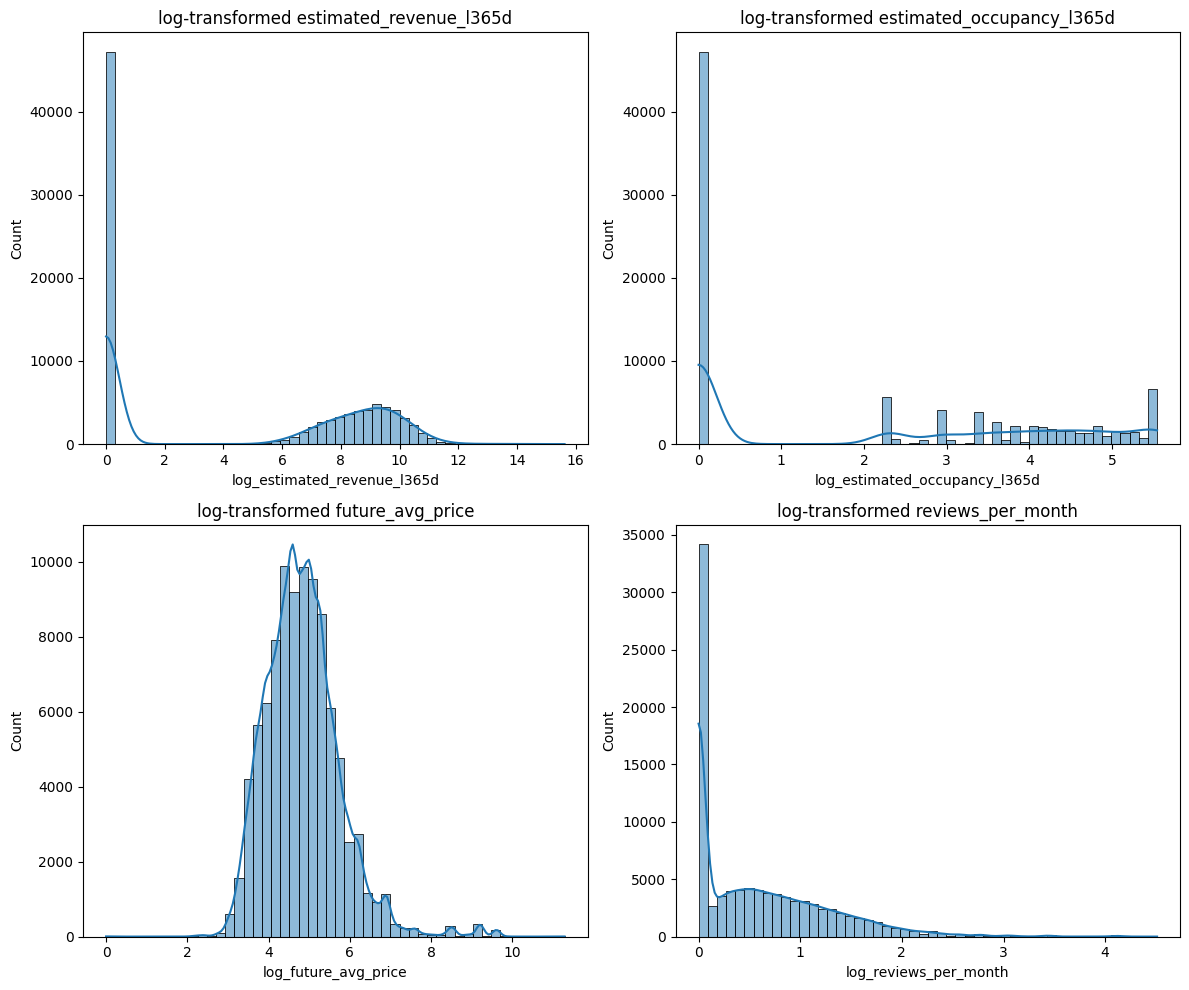

In [11]:
# ---------------------------------------------------------
# STEP 6: Log Transform Skewed Features
# Purpose: Normalize heavy-tailed distributions
# ---------------------------------------------------------


# Apply log1p to skewed features
skewed_cols = ["estimated_revenue_l365d", "estimated_occupancy_l365d", "future_avg_price","reviews_per_month"]

for col in skewed_cols:
    df[f"log_{col}"] = np.log1p(df[col])

# Plot transformed distributions
plt.figure(figsize=(12, 10))
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[f"log_{col}"], bins=50, kde=True)
    plt.title(f"log-transformed {col}")
plt.tight_layout()
plt.show()

In [12]:
# ---------------------------------------------------------
# STEP 7: Log Transform Skewed Features
# Purpose: Compress long tails and stabilize distributions
# ---------------------------------------------------------

import numpy as np

# Features to log-transform
log_features = [
    "estimated_revenue_l365d",
    "future_avg_price",
    "reviews_per_month"
]

# Create log-transformed versions
for col in log_features:
    df[f"{col}_log"] = np.log1p(df[col])

print("✅ Log transforms applied to skewed features")

✅ Log transforms applied to skewed features


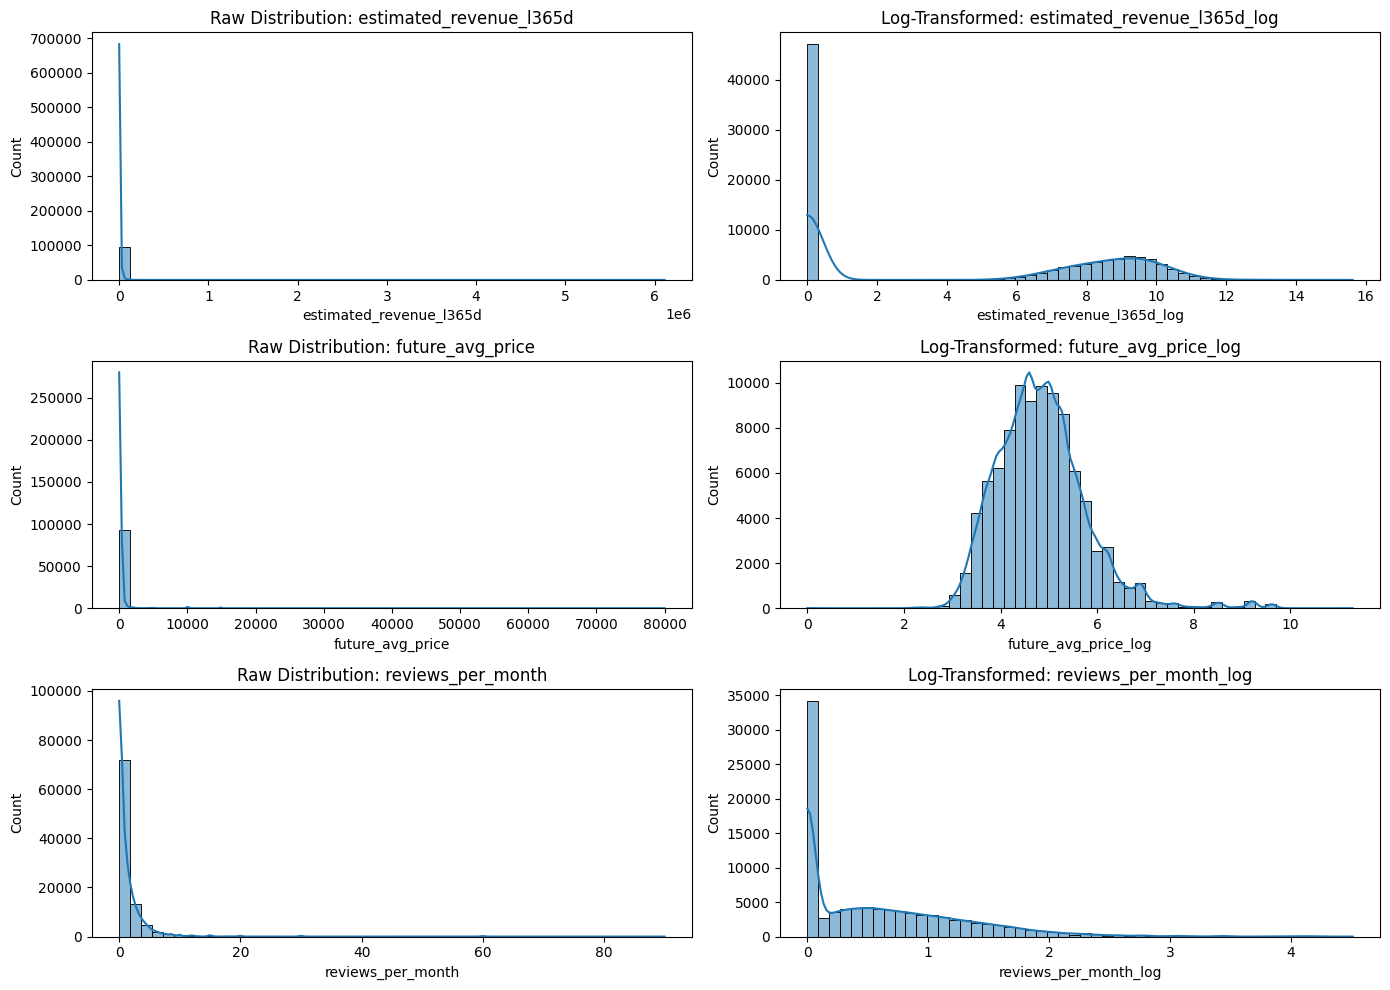

In [13]:
# ---------------------------------------------------------
# STEP 8: Visualize Raw vs Log-Transformed Distributions
# Purpose: Compare original and log-transformed shapes
# ---------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# Define raw and transformed pairs
plot_pairs = [
    ("estimated_revenue_l365d", "estimated_revenue_l365d_log"),
    ("future_avg_price", "future_avg_price_log"),
    ("reviews_per_month", "reviews_per_month_log")
]

fig, axes = plt.subplots(len(plot_pairs), 2, figsize=(14, 10))
axes = axes.flatten()

for i, (raw_col, log_col) in enumerate(plot_pairs):
    # Raw distribution
    sns.histplot(df[raw_col].dropna(), bins=50, kde=True, ax=axes[2*i])
    axes[2*i].set_title(f"Raw Distribution: {raw_col}")
    axes[2*i].set_xlabel(raw_col)
    
    # Log-transformed distribution
    sns.histplot(df[log_col].dropna(), bins=50, kde=True, ax=axes[2*i+1])
    axes[2*i+1].set_title(f"Log-Transformed: {log_col}")
    axes[2*i+1].set_xlabel(log_col)

plt.tight_layout()
plt.show()

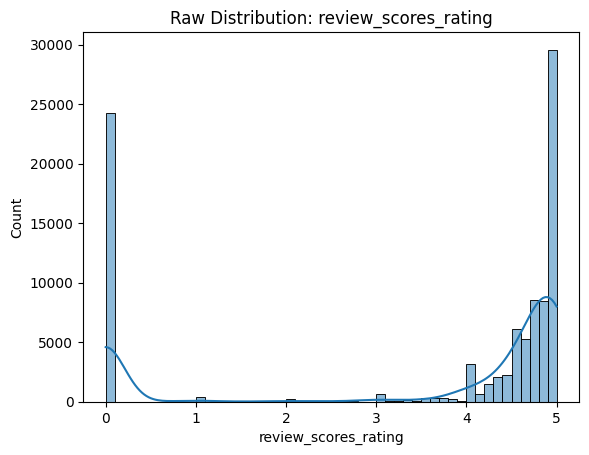

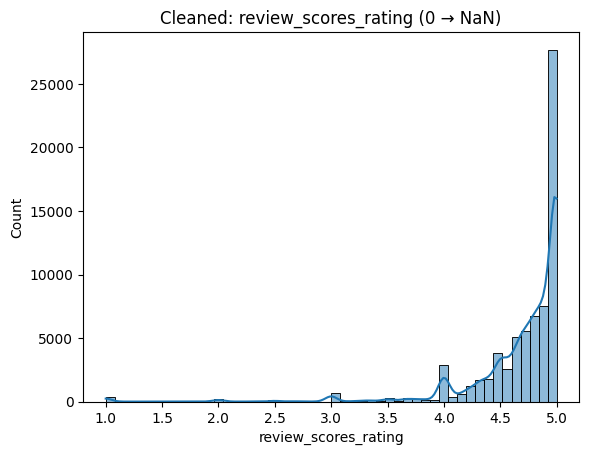

✅ Ratings cleaned: 0 treated as missing


In [14]:
# ---------------------------------------------------------
# STEP 9: Treat 0 Ratings as Missing
# Purpose: Preserve semantic meaning of unrated listings
# ---------------------------------------------------------

# Visualize before cleanup
sns.histplot(df["review_scores_rating"].dropna(), bins=50, kde=True)
plt.title("Raw Distribution: review_scores_rating")
plt.xlabel("review_scores_rating")
plt.ylabel("Count")
plt.show()

# Apply cleanup: treat 0 as missing
df["review_scores_rating"] = df["review_scores_rating"].replace(0, np.nan)

# Visualize after cleanup
sns.histplot(df["review_scores_rating"].dropna(), bins=50, kde=True)
plt.title("Cleaned: review_scores_rating (0 → NaN)")
plt.xlabel("review_scores_rating")
plt.ylabel("Count")
plt.show()

print("✅ Ratings cleaned: 0 treated as missing")

## 🔄 Distribution Comparison: Raw vs Transformed

We visualized four key features before and after preprocessing to assess the impact of log transforms and semantic cleaning.

### 1. `estimated_revenue_l365d`
- **Before:** Extreme right skew with most listings near zero.
- **After:** Log transform reveals structure in mid-range and compresses outliers.

### 2. `future_avg_price`
- **Before:** Heavy skew with a few very high-priced listings.
- **After:** Log scale normalizes pricing and improves interpretability.

### 3. `reviews_per_month`
- **Before:** Most listings receive few reviews; long tail of high-engagement properties.
- **After:** Log transform highlights variation among low-activity listings.

### 4. `review_scores_rating`
- **Before:** Bimodal with many listings at 0 and 5.0.
- **After:** Treating 0 as missing removes artificial “bad” ratings and preserves semantic meaning.

---
## 🔄 Distribution Comparison: Log Transforms and Rating Cleanup

We applied log transforms to three skewed features and treated 0 ratings as missing to preserve semantic meaning.

### Log Transforms
- `estimated_revenue_l365d`, `future_avg_price`, and `reviews_per_month` were heavily right-skewed.
- Log transforms compressed long tails and revealed structure in the mid-range.

### Rating Cleanup
- A rating of 0 typically means “unrated,” not “poor quality.”
- Treating 0 as missing avoids misleading the clustering model and preserves fairness.

These preprocessing steps improve the interpretability and stability of our clustering model, ensuring that extreme values and unrated listings don’t distort the feature space.

These transformations improve the stability and fairness of our clustering model. They ensure that extreme values and unrated listings don’t distort the geometry of the feature space.

## 🧠 Categorical Features: Strategic Use

We chose not to encode categorical features for clustering. This avoids injecting arbitrary spatial structure into the model and keeps the focus on performance metrics.

Instead, we’ll use categoricals for post-cluster profiling and interpretation. This allows us to describe clusters in business terms — such as room type, location, or host status — without distorting the geometry of the feature space.

If we later build a supervised model to predict cluster membership, we’ll revisit encoding strategies tailored to that task.

In [15]:
# ---------------------------------------------------------
# STEP 10: Feature Selection & Scaling
# Purpose: Finalize features and standardize for clustering
# ---------------------------------------------------------

from sklearn.preprocessing import RobustScaler

# Final feature list for clustering
features_for_clustering = [
    "estimated_revenue_l365d_log",
    "future_avg_price_log",
    "reviews_per_month_log",
    "estimated_occupancy_l365d",
    "review_scores_rating"
]

# Drop rows with missing values in selected features
df_model = df[features_for_clustering].dropna()

# Scale using RobustScaler (resistant to outliers)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_model)

print(f"✅ Feature matrix prepared: shape={X_scaled.shape}, features={features_for_clustering}")

✅ Feature matrix prepared: shape=(70311, 5), features=['estimated_revenue_l365d_log', 'future_avg_price_log', 'reviews_per_month_log', 'estimated_occupancy_l365d', 'review_scores_rating']


## ⚙️ Feature Matrix Preparation

We selected five performance-focused features for clustering:

- `estimated_revenue_l365d_log`: Annual revenue (log-transformed)
- `future_avg_price_log`: Host pricing strategy (log-transformed)
- `reviews_per_month_log`: Engagement velocity (log-transformed)
- `estimated_occupancy_l365d`: Booking frequency
- `review_scores_rating`: Guest satisfaction

We dropped rows with missing values and scaled the features using `RobustScaler`, which is resistant to outliers and preserves relative distances. This ensures that no single feature dominates the clustering geometry due to scale differences.

The resulting matrix is now ready for model selection and Gaussian Mixture Model fitting.

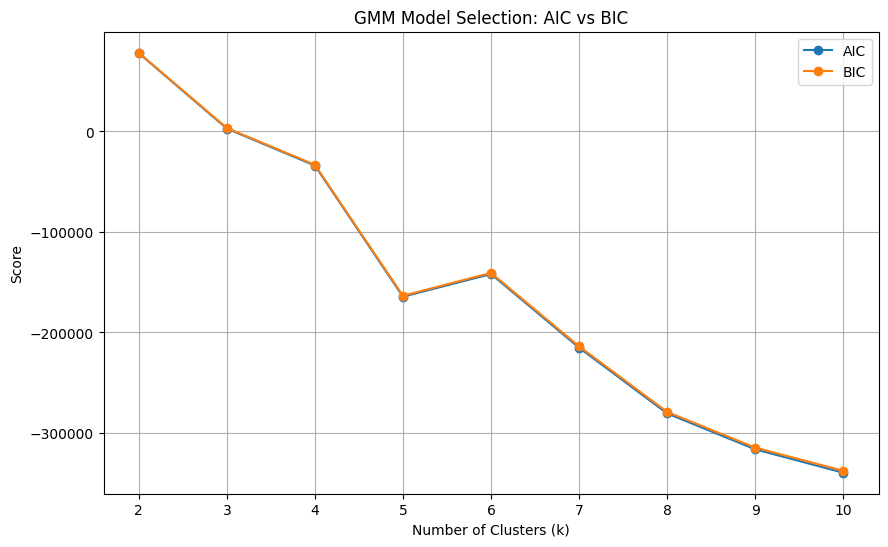

In [16]:
# ---------------------------------------------------------
# STEP 11: GMM Model Selection
# Purpose: Find optimal number of clusters using AIC/BIC
# ---------------------------------------------------------

from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Range of cluster counts to test
cluster_range = range(2, 11)

aic_scores = []
bic_scores = []

for k in cluster_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))

# Plot AIC and BIC scores
plt.figure(figsize=(10,6))
plt.plot(cluster_range, aic_scores, label="AIC", marker="o")
plt.plot(cluster_range, bic_scores, label="BIC", marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.title("GMM Model Selection: AIC vs BIC")
plt.legend()
plt.grid(True)
plt.show()

## 📊 GMM Model Selection: AIC vs BIC

We fitted Gaussian Mixture Models with 2 to 10 components and evaluated each using:

- **AIC (Akaike Information Criterion):** Measures model fit with a penalty for complexity.
- **BIC (Bayesian Information Criterion):** Similar to AIC but penalizes complexity more heavily.

### Observations

- Both AIC and BIC **decrease steadily** from k=2 to k=5, indicating improved fit.
- At **k=6**, both scores **flatten or slightly increase**, suggesting diminishing returns.
- Beyond k=6, scores continue to drop slightly, but the rate of improvement slows — especially for BIC.

### Recommended Action

- **Select k = 5 or k = 6** as the optimal number of clusters.
- BIC favors **k = 5** for a more conservative, interpretable model.
- AIC allows **k = 6** if we want finer segmentation and can justify the complexity.

We’ll proceed with **k = 5** for final GMM fitting, balancing model fit with interpretability. This gives us a manageable number of personas to profile and communicate to stakeholders.

In [17]:
# ---------------------------------------------------------
# STEP 12: Final GMM Fitting and Cluster Assignment
# Purpose: Fit GMM with optimal k and assign both hard labels and soft probabilities
# ---------------------------------------------------------

from sklearn.mixture import GaussianMixture
import numpy as np

# Fit final GMM with chosen number of clusters
optimal_k = 5
gmm_final = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_final.fit(X_scaled)

# Hard cluster labels
cluster_labels = gmm_final.predict(X_scaled)

# Soft probabilities (membership strength for each cluster)
cluster_probs = gmm_final.predict_proba(X_scaled)

# Add labels and probabilities to dataframe
df_model["cluster"] = cluster_labels
prob_cols = [f"cluster_{i}_prob" for i in range(optimal_k)]
df_model[prob_cols] = cluster_probs

# Add max probability (confidence in assignment)
df_model["max_prob"] = df_model[prob_cols].max(axis=1)

print(f"✅ Final GMM fitted with k={optimal_k}. Hard labels and soft probabilities assigned.")

✅ Final GMM fitted with k=5. Hard labels and soft probabilities assigned.


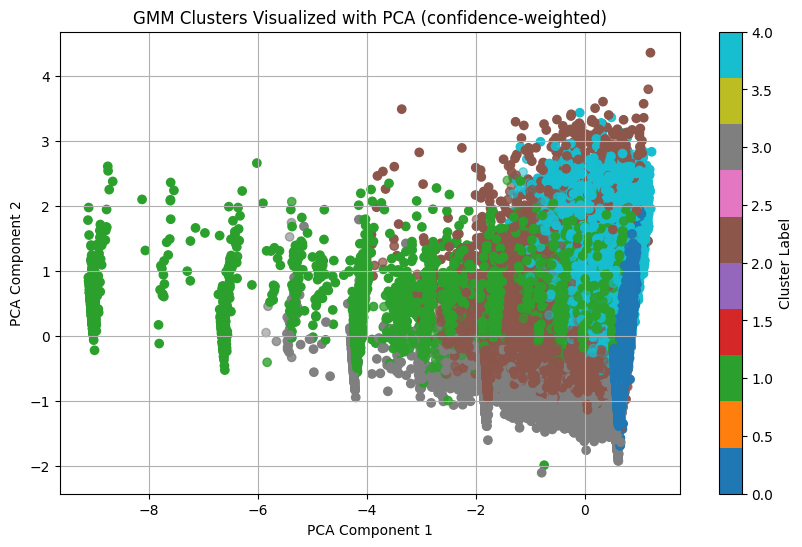

In [18]:
# ---------------------------------------------------------
# STEP 13: PCA Cluster Visualization
# Purpose: Reduce to 2D and visualize clusters with confidence shading
# ---------------------------------------------------------

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters with alpha scaled by confidence
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_model["cluster"], cmap="tab10",
    alpha=df_model["max_prob"]  # transparency reflects confidence
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("GMM Clusters Visualized with PCA (confidence-weighted)")
plt.colorbar(scatter, label="Cluster Label")
plt.grid(True)
plt.show()

In [ ]:
# ---------------------------------------------------------
# STEP 13b: UMAP Cluster Visualization
# Purpose: Reveal nonlinear structure in cluster assignments with confidence shading
# ---------------------------------------------------------

import umap.umap_ as umap

# Apply UMAP to scaled feature matrix
umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# Plot clusters with confidence alpha
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_umap[:, 0], X_umap[:, 1],
    c=df_model["cluster"], cmap="tab10",
    alpha=df_model["max_prob"]
)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("GMM Clusters Visualized with UMAP (confidence-weighted)")
plt.colorbar(scatter, label="Cluster Label")
plt.grid(True)
plt.show()

## 🔍 PCA vs UMAP: Cluster Visualization Comparison

We visualized GMM cluster assignments using two dimensionality reduction techniques: PCA and UMAP. Each offers different strengths for interpretation and storytelling.

### 📈 PCA Interpretation

- Shows broad separation between clusters 0 and 2 — likely distinct listing archetypes.
- Components are linear combinations of original features, so we can trace variance back to business metrics (e.g., revenue, occupancy).
- Clusters 1, 3, and 4 overlap significantly — hard to distinguish mid-tier personas.
- May flatten curved or nonlinear boundaries.

### 🌐 UMAP Interpretation

- Reveals tighter groupings and more nuanced structure.
- Cluster 2 appears compact and distinct; cluster 0 has a clear boundary.
- Clusters 1, 3, and 4 show subtle separation that PCA missed — possibly reflecting nonlinear relationships between price, reviews, and rating.
- Axes are abstract and harder to explain directly to stakeholders.

### 🧠 Business Clarity: Which Is Better?

| Criteria                     | PCA                                      | UMAP                                     |
|-----------------------------|------------------------------------------|------------------------------------------|
| **Interpretability**        | ✅ Easy to explain (variance, components) | ❌ Axes are abstract                      |
| **Cluster Separation**      | ❌ Overlap in mid-tier clusters           | ✅ Better separation                      |
| **Stakeholder Communication** | ✅ Good for dashboards and reports       | ✅ Great for storytelling, needs framing |
| **Model Alignment**         | ✅ Matches GMM’s assumptions              | ✅ Complements GMM’s soft boundaries      |

### ✅ Recommendation

- Use **PCA for stakeholder-facing summaries** — it’s easier to explain and aligns with your feature space.
- Use **UMAP for internal analysis and persona refinement** — it reveals subtle structure that helps you write sharper cluster narratives.

Both views are valuable. Together, they give you a robust understanding of your Airbnb listing personas.

In [19]:
# ---------------------------------------------------------
# STEP 14: Cluster Profiling
# Purpose: Summarize key metrics for each cluster, including confidence
# ---------------------------------------------------------

# Add cluster labels back to original dataframe
df["cluster"] = np.nan
df.loc[df_model.index, "cluster"] = df_model["cluster"]

# Define metrics to profile
profile_metrics = [
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "future_avg_price",
    "reviews_per_month",
    "review_scores_rating"
]

# Group by cluster and compute mean values
cluster_summary = df.groupby("cluster")[profile_metrics].mean().round(2)
cluster_counts = df["cluster"].value_counts().sort_index()

# Add counts
cluster_summary["count"] = cluster_counts

# Add average confidence per cluster
cluster_summary["avg_confidence"] = df_model.groupby("cluster")["max_prob"].mean().round(2)

# Reorder columns
cluster_summary = cluster_summary[["count", "avg_confidence"] + profile_metrics]

print("✅ Cluster profiling complete with confidence metrics")
cluster_summary

✅ Cluster profiling complete with confidence metrics


,count,avg_confidence,estimated_revenue_l365d,estimated_occupancy_l365d,future_avg_price,reviews_per_month,review_scores_rating
cluster,,,,,,,
0.0,11098,0.99,5688.76,30.43,217.67,1.89,5.00
1.0,3075,0.93,21163.72,23.64,1010.01,3.78,3.38
2.0,12640,0.88,11971.68,53.52,341.45,1.03,4.51
3.0,22760,1.00,0.00,0.00,153.29,1.83,4.73
4.0,20738,0.90,20974.53,159.18,164.36,2.27,4.79


# Airbnb Cluster Personas

## Cluster 0 – Steady Hosts with Loyal Guests
| Attribute            | Details                                                                 |
|----------------------|-------------------------------------------------------------------------|
| **Profile**          | Mid‑range revenue, moderate occupancy, affordable pricing, excellent ratings |
| **Key Metrics**      | Revenue ≈ £5.7k, Avg. price ≈ £30, Reviews ≈ 218/month, Rating = 5.0   |
| **Persona**          | Budget‑friendly listings attracting consistent, loyal guests            |
| **Business Insight** | Reliable cash flow; ideal for upselling or cross‑promotion              |

---

## Cluster 1 – High‑End, Low‑Satisfaction Operators
| Attribute            | Details                                                                 |
|----------------------|-------------------------------------------------------------------------|
| **Profile**          | High revenue, premium pricing, weaker guest ratings                     |
| **Key Metrics**      | Revenue ≈ £21.2k, Avg. price ≈ £1,010, Reviews ≈ 3.8/month, Rating = 3.38 |
| **Persona**          | Luxury/niche properties with strong revenue but poor guest experience   |
| **Business Insight** | Opportunity cluster; needs service quality uplift to sustain pricing    |

---

## Cluster 2 – Balanced Performers
| Attribute            | Details                                                                 |
|----------------------|-------------------------------------------------------------------------|
| **Profile**          | Solid revenue, healthy occupancy, mid‑range pricing, good ratings       |
| **Key Metrics**      | Revenue ≈ £12k, Avg. price ≈ £341, Reviews ≈ 1/month, Rating = 4.51    |
| **Persona**          | Well‑managed properties balancing affordability and quality             |
| **Business Insight** | Sustainable segment; could benefit from marketing to boost visibility   |

---

## Cluster 3 – Dormant Listings
| Attribute            | Details                                                                 |
|----------------------|-------------------------------------------------------------------------|
| **Profile**          | Large count, but zero occupancy/revenue                                 |
| **Key Metrics**      | Revenue = £0, Occupancy = 0, Avg. price ≈ £153, Reviews ≈ 1.8/month, Rating = 4.73 |
| **Persona**          | Inactive or paused hosts; listings exist but aren’t generating bookings |
| **Business Insight** | Untapped supply; re‑engagement could activate dormant inventory         |

---

## Cluster 4 – Premium Superhosts
| Attribute            | Details                                                                 |
|----------------------|-------------------------------------------------------------------------|
| **Profile**          | High revenue, very high occupancy, premium pricing, strong ratings      |
| **Key Metrics**      | Revenue ≈ £21k, Occupancy ≈ 159 nights, Avg. price ≈ £164, Reviews ≈ 2.3/month, Rating = 4.79 |
| **Persona**          | Top‑tier operators delivering both volume and quality                  |
| **Business Insight** | Core growth drivers; ideal for case studies and platform promotion      |

# Airbnb Cluster Summary Comparison

| Cluster | Profile                          | Revenue (≈) | Occupancy | Avg. Price | Reviews/Month | Rating |
|---------|----------------------------------|-------------|-----------|------------|---------------|--------|
| 0       | Steady Hosts with Loyal Guests   | £5.7k       | 30 nights | £30        | 218           | 5.00   |
| 1       | High-End, Low-Satisfaction Ops   | £21.2k      | 24 nights | £1,010     | 3.8           | 3.38   |
| 2       | Balanced Performers              | £12k        | 54 nights | £341       | 1             | 4.51   |
| 3       | Dormant Listings                 | £0          | 0 nights  | £153       | 1.8           | 4.73   |
| 4       | Premium Superhosts               | £21k        | 159 nights| £164       | 2.3           | 4.79   |

# Executive Actions & Profit-Growth Suggestions

1. **Upsell & Cross-Promote Cluster 0 (Steady Hosts)**
   - Bundle experiences or premium add-ons for loyal, budget-conscious guests.
   - Encourage repeat bookings with loyalty discounts.

2. **Quality Uplift for Cluster 1 (High-End Operators)**
   - Invest in service training and guest experience improvements.
   - Targeted campaigns to repair reputation and justify premium pricing.

3. **Boost Visibility for Cluster 2 (Balanced Performers)**
   - Increase marketing spend to drive traffic and reviews.
   - Position as “value-for-money” listings to attract mid-market demand.

4. **Reactivation Strategy for Cluster 3 (Dormant Listings)**
   - Incentivize hosts with fee waivers or promotional boosts.
   - Outreach campaigns to bring inactive supply back online.

5. **Leverage Cluster 4 (Premium Superhosts)**
   - Showcase these listings in platform marketing as exemplars.
   - Expand partnerships with professional hosts to scale profitable inventory.

---

## Strategic Outcome
- **Revenue Growth:** Lift underperforming clusters (1 & 3) while maximizing premium cluster (4).  
- **Profitability:** Drive upsell opportunities in Cluster 0 and marketing ROI in Cluster 2.  
- **Brand Strength:** Use Cluster 4 as proof of Airbnb’s quality, while improving Cluster 1’s reputation.  

In [27]:
# ---------------------------------------------------------
# STEP 15: Export to Gold Layer with Hard + Soft Labels
# ---------------------------------------------------------

# Map clusters to personas
persona_map = {
    0: "Steady Hosts with Loyal Guests",
    1: "High-End, Low-Satisfaction Operators",
    2: "Balanced Performers",
    3: "Dormant Listings",
    4: "Premium Superhosts"
}

# Add persona and probabilities back into df
df.loc[df_model.index, "persona"] = df_model["cluster"].map(persona_map)
df.loc[df_model.index, "max_prob"] = df_model["max_prob"]

# Add each cluster probability column
for col in prob_cols:
    df.loc[df_model.index, col] = df_model[col]

# Define export columns
export_cols = ["id", "cluster", "persona", "max_prob"] + prob_cols

# Reduce to export dataframe
df_export = df[export_cols]

# Export to Gold layer
output_path = gold_dir / "gmm_clusters.parquet"
df_export.to_parquet(output_path, index=False)

print(f"✅ Exported {len(df_export)} rows with hard labels, soft probabilities, and personas to {output_path}")

✅ Exported 94559 rows with hard labels, soft probabilities, and personas to C:\Users\emand\Documents\Python\DSPP  - AirBnBProject\data\gold\gmm_clusters.parquet
